In [1]:
%pip install tensorflow nbformat ipython ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install -q xgboost lightgbm shap imbalanced-learn plotly scikit-learn seaborn
import warnings; warnings.filterwarnings('ignore') 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px 

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score 
from sklearn.preprocessing import LabelEncoder, RobustScaler, MinMaxScaler 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import ( confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score, f1_score, accuracy_score, ConfusionMatrixDisplay ) 
from sklearn.calibration import calibration_curve 
from imblearn.over_sampling import SMOTE 
import xgboost as xgb 
import lightgbm as lgb 
import shap 
import tensorflow as tf 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense, Dropout, LSTM, Bidirectional, BatchNormalization 
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau 
from tensorflow.keras.optimizers import Adam 
plt.rcParams['figure.figsize'] = (14, 6) 
sns.set_theme(style='whitegrid', palette='husl') 
print(f'Ready | TF {tf.__version__} | XGB {xgb.__version__} | LGB {lgb.__version__}')

Note: you may need to restart the kernel to use updated packages.
Ready | TF 2.21.0 | XGB 3.2.0 | LGB 4.6.0


In [3]:
df_raw = pd.read_csv("../data/dataset/dataset.csv")

DATE_COLS = ['event_started_on','event_confirmed_on','event_ended_on',
             'outbreak_start_date','outbreak_end_date','reported_on']
for c in DATE_COLS:
    df_raw[c] = pd.to_datetime(df_raw[c], errors='coerce', utc=True)

df_raw['year']    = df_raw['event_started_on'].dt.year
df_raw['month']   = df_raw['event_started_on'].dt.month
df_raw['quarter'] = df_raw['event_started_on'].dt.quarter

print(f'Loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} cols')
print(f'Countries: {df_raw["country_name"].nunique()} | Diseases: {df_raw["disease_name"].nunique()}')
df_raw.head(3)

Loaded: 6,363 rows × 51 cols
Countries: 194 | Diseases: 208


,event_id,country_name,iso_code,admin_division,disease_name,disease_subtype,disease_group,causal_agent_type,species_name,is_wild,...,intervention_treatment_applied,intervention_slaughter_applied,intervention_count,lab_test_performed,diagnostic_method_types,event_status,reason_type,year,month,quarter
0,1,Argentina,ARG,Buenos Aires,West Nile Fever,NaN,Multiple species,Virus,Equidae,0.0,...,0,0,6,5,Diagnostic test|Clinical,Resolved,First occurrence,2006,2,1
1,3,Japan,JPN,Fukuoka,Newcastle disease,NaN,Aves,Virus,Birds,0.0,...,0,0,6,3,Diagnostic test|Clinical,Resolved,Recurrence,2006,3,1
2,4,Denmark,DNK,Fyns Amt (2005-2007),Highly pathogenic avian influenza,H5N1,Aves,Virus,Birds,0.0,...,0,0,0,1,Diagnostic test|Clinical,Resolved,First occurrence,2006,5,2


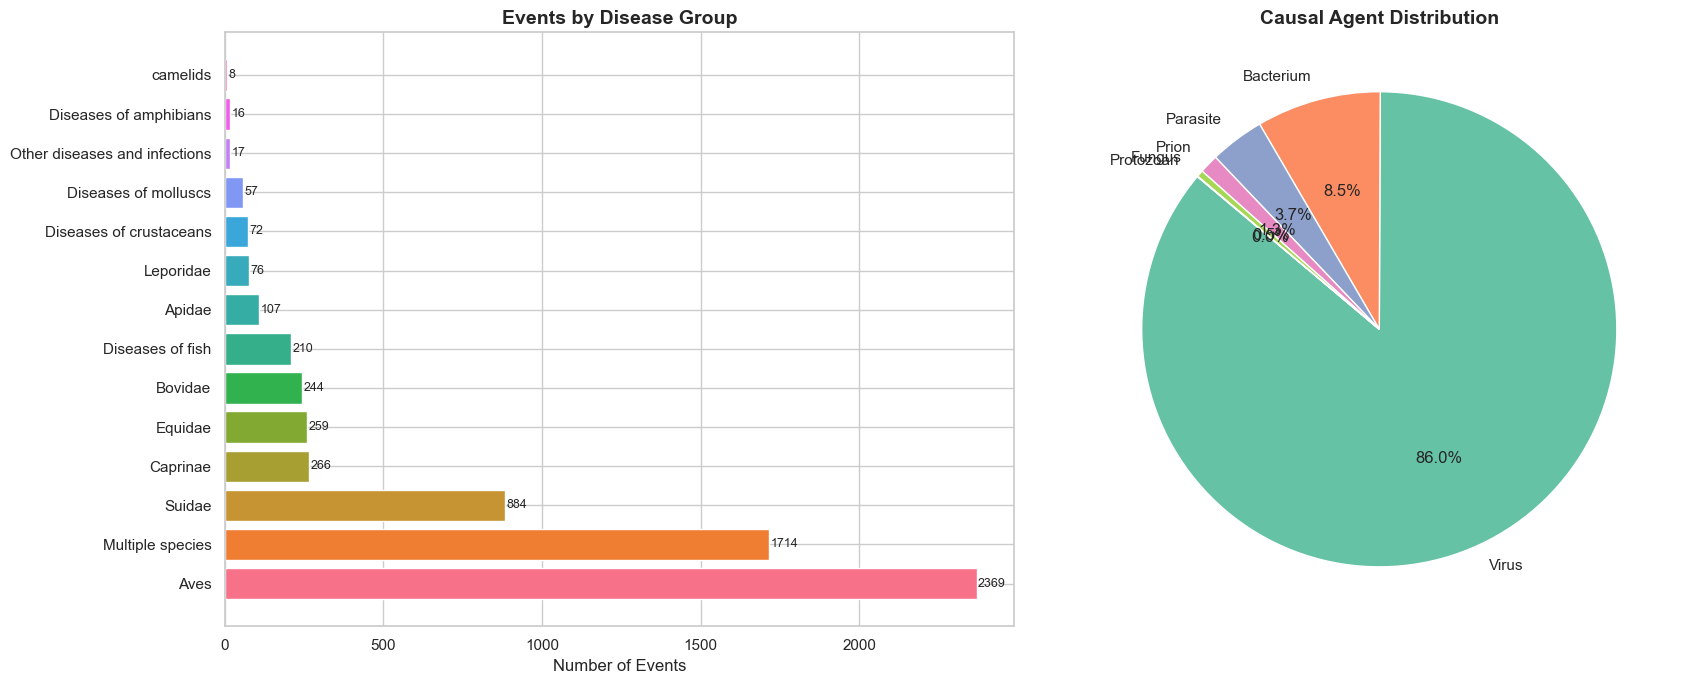

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
dg = df_raw['disease_group'].value_counts()
axes[0].barh(dg.index, dg.values, color=sns.color_palette('husl', len(dg)))
axes[0].set_title('Events by Disease Group', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Events')
for i, v in enumerate(dg.values): axes[0].text(v+5, i, str(v), va='center', fontsize=9)
ca = df_raw['causal_agent_type'].value_counts()
axes[1].pie(ca.values, labels=ca.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(ca)), startangle=140)
axes[1].set_title('Causal Agent Distribution', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('fig1_eda.png', dpi=150, bbox_inches='tight'); plt.show()

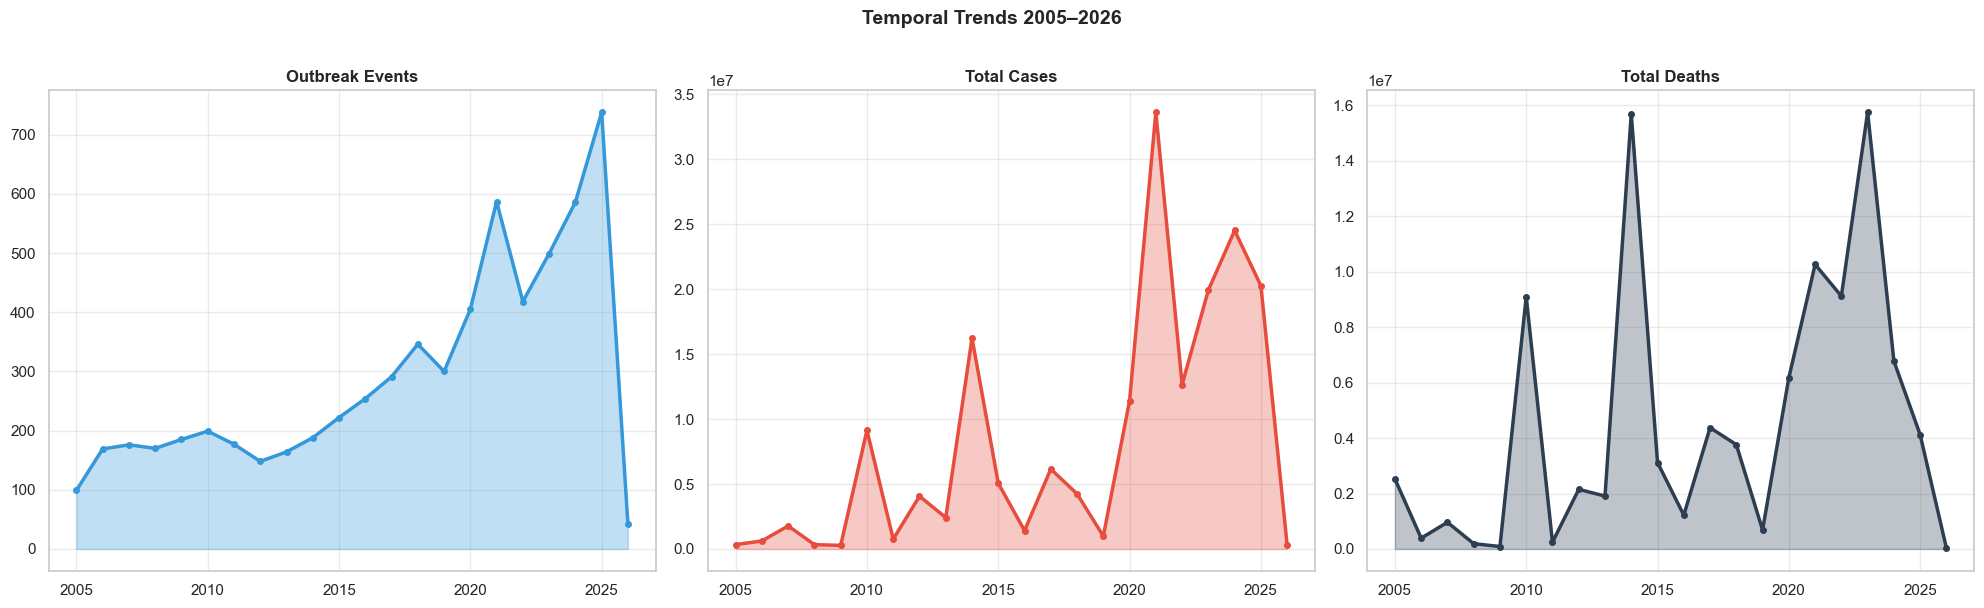

In [5]:
yearly = df_raw.groupby('year').agg(events=('event_id','count'),
    cases=('cases','sum'), deaths=('deaths','sum')).reset_index().dropna()
fig, axes = plt.subplots(1,3,figsize=(20,6))
for ax, col, clr, lbl in zip(axes,['events','cases','deaths'],
    ['#3498DB','#E74C3C','#2C3E50'],['Outbreak Events','Total Cases','Total Deaths']):
    ax.fill_between(yearly['year'], yearly[col], alpha=0.3, color=clr)
    ax.plot(yearly['year'], yearly[col], color=clr, lw=2.5, marker='o', ms=4)
    ax.set_title(lbl, fontsize=12, fontweight='bold'); ax.grid(True, alpha=0.4)
plt.suptitle('Temporal Trends 2005–2026', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('fig2_trends.png', dpi=150, bbox_inches='tight'); plt.show()

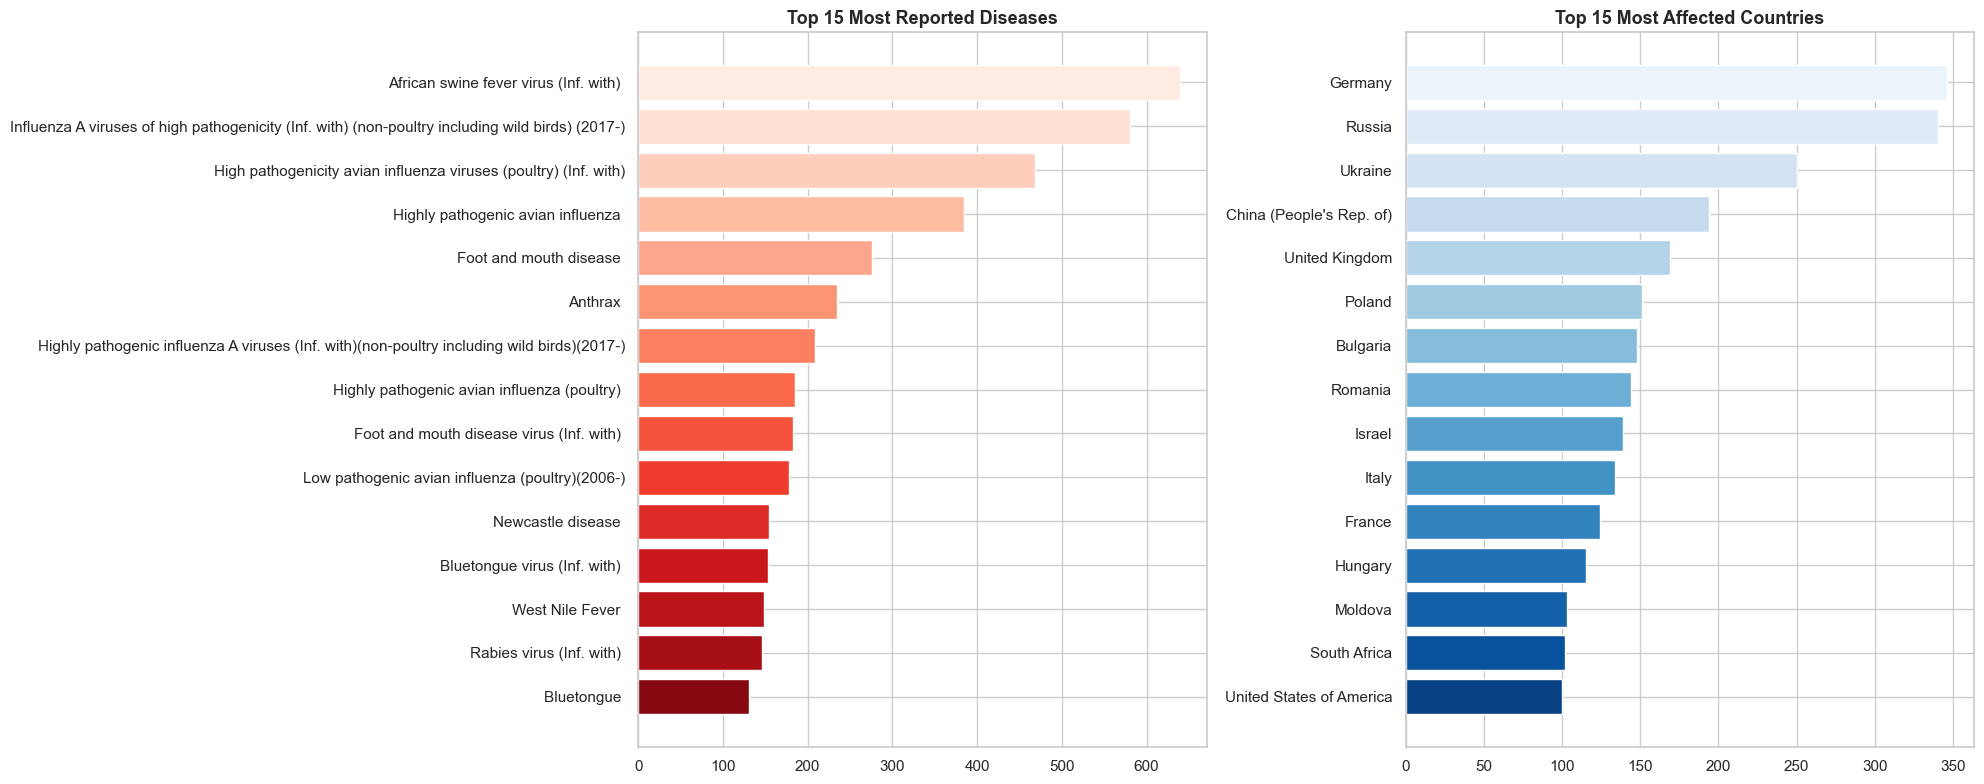

In [6]:
fig, axes = plt.subplots(1,2,figsize=(20,8))
td = df_raw['disease_name'].value_counts().head(15)
axes[0].barh(td.index[::-1], td.values[::-1], color=sns.color_palette('Reds_r',15))
axes[0].set_title('Top 15 Most Reported Diseases', fontsize=13, fontweight='bold')
tc = df_raw['country_name'].value_counts().head(15)
axes[1].barh(tc.index[::-1], tc.values[::-1], color=sns.color_palette('Blues_r',15))
axes[1].set_title('Top 15 Most Affected Countries', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('fig3_top.png', dpi=150, bbox_inches='tight'); plt.show()

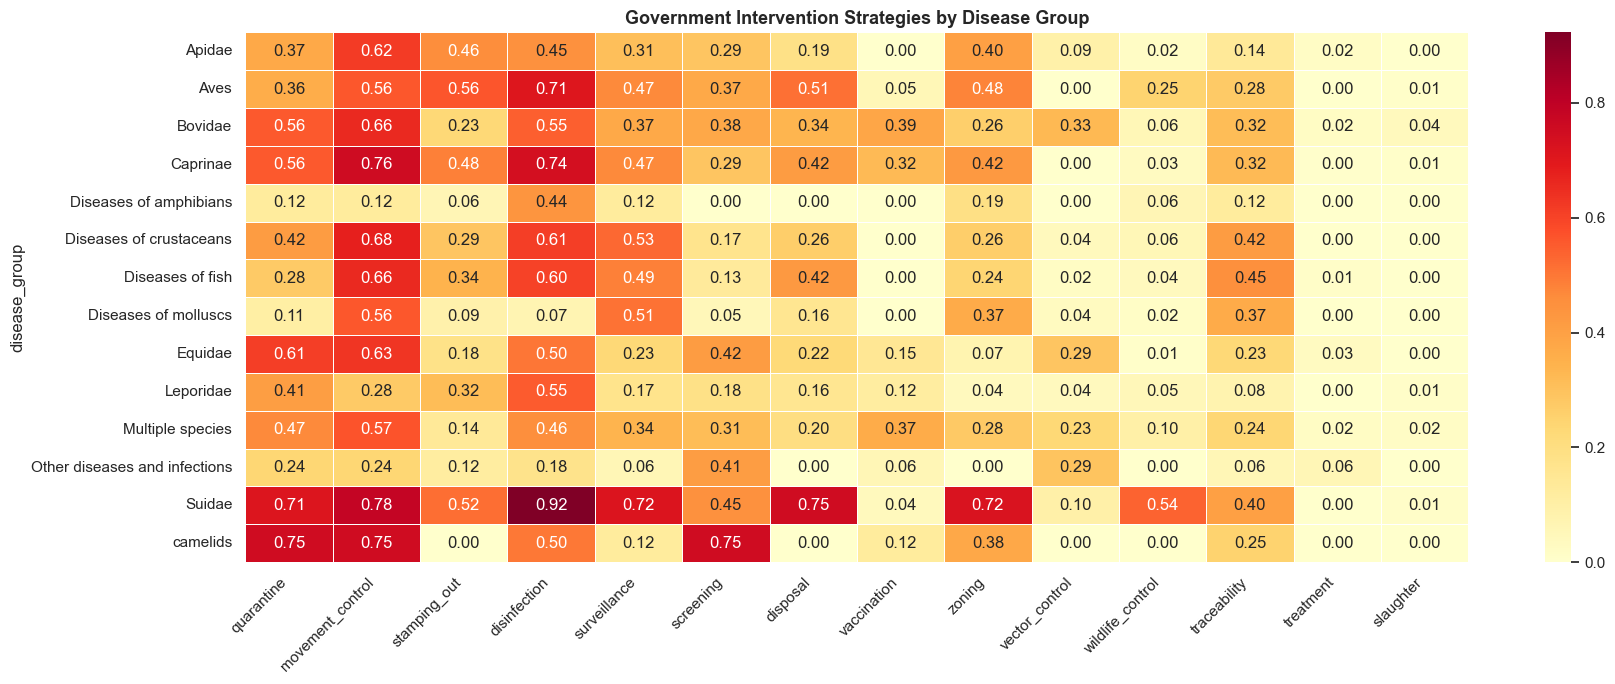

In [7]:
int_cols_all = [c for c in df_raw.columns if 'intervention_' in c and c != 'intervention_count']
int_df = df_raw.groupby('disease_group')[int_cols_all].mean()
int_df.columns = [c.replace('intervention_','').replace('_applied','') for c in int_df.columns]
plt.figure(figsize=(18,7))
sns.heatmap(int_df, cmap='YlOrRd', annot=True, fmt='.2f', linewidths=0.5)
plt.title('Government Intervention Strategies by Disease Group', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig('fig4_interventions.png', dpi=150, bbox_inches='tight'); plt.show()

In [8]:
geo = df_raw.dropna(subset=['latitude','longitude'])
fig_map = px.scatter_geo(geo.sample(min(3000,len(geo)),random_state=42),
    lat='latitude', lon='longitude', color='causal_agent_type',
    hover_data=['country_name','disease_name','cases','deaths'],
    title='Global Animal Disease Outbreak Distribution',
    opacity=0.6, projection='natural earth',
    color_discrete_sequence=px.colors.qualitative.Set1)
fig_map.update_layout(height=520); fig_map.write_html('fig5_map.html'); fig_map.show()

In [9]:
eps = 1e-9
df_sev = df_raw.copy()

df_sev['cfr']         = (df_sev['deaths'] / (df_sev['cases'] + eps)).clip(0, 1)
df_sev['attack_rate'] = (df_sev['cases']  / (df_sev['susceptible'] + eps)).clip(0, 1)
df_sev['kill_ratio']  = (df_sev['killed'] / (df_sev['cases'] + eps)).clip(0, 5) / 5.0  # normalize 0-1
df_sev['duration_days'] = (
    (df_sev['event_ended_on'] - df_sev['event_started_on']).dt.days
).clip(0, 730).fillna(30) / 730.0  # normalize 0-1 (max 2 years)
df_sev['is_emerging'] = df_sev['reason_type'].isin([
    'Emerging disease','Unexpected change or increase','New strain',
    'New strain in the country','New strain in a zone or a compartment',
    'New pathogen strain or disease manifestation']).astype(float)
df_sev['is_recurrence'] = df_sev['reason_type'].isin([
    'Recurrence','Recurrence of an eradicated disease',
    'Recurrence of an eradicated strain']).astype(float)

W_CFR, W_AR, W_KR, W_DUR, W_EMERG, W_RECUR = 0.30, 0.25, 0.15, 0.10, 0.12, 0.08

df_sev['ecsi_raw'] = (
    W_CFR   * df_sev['cfr'] +
    W_AR    * df_sev['attack_rate'] +
    W_KR    * df_sev['kill_ratio'] +
    W_DUR   * df_sev['duration_days'] +
    W_EMERG * df_sev['is_emerging'] +
    W_RECUR * df_sev['is_recurrence']
)
df_sev['ecsi'] = (df_sev['ecsi_raw'] * 100).clip(0, 100).round(2)

def ecsi_band(score):
    if score < 20:  return 'Minimal'
    elif score < 40: return 'Low'
    elif score < 60: return 'Moderate'
    elif score < 80: return 'High'
    else:            return 'Critical'

df_sev['ecsi_band'] = df_sev['ecsi'].apply(ecsi_band)

print('ECSI Distribution:')
print(df_sev['ecsi_band'].value_counts())
print(f'\nMean ECSI: {df_sev["ecsi"].mean():.1f} | Max: {df_sev["ecsi"].max():.1f}')

ECSI Distribution:
ecsi_band
Moderate    2011
Low         1788
Minimal     1504
High        1060
Name: count, dtype: int64

Mean ECSI: 38.2 | Max: 76.5


In [10]:
def safe_mode(x):
    vals = x.dropna()
    return vals.value_counts().index[0] if len(vals) > 0 else 'Unknown'

int_cols = [c for c in df_raw.columns if 'intervention_' in c and c != 'intervention_count']

def build_severity_profile(grp):
    cfr_v   = (grp['deaths'] / (grp['cases'] + eps)).clip(0,1).mean()
    ar_v    = (grp['cases'] / (grp['susceptible'] + eps)).clip(0,1).mean()
    kr_v    = (grp['killed'] / (grp['cases'] + eps)).clip(0,5).mean() / 5.0
    dur_v   = (grp['event_ended_on'] - grp['event_started_on']).dt.days.clip(0,730).fillna(30).mean() / 730.0
    emg_v   = grp['is_emerging'].mean()
    rec_v   = grp['is_recurrence'].mean()
    ecsi_v  = (W_CFR*cfr_v + W_AR*ar_v + W_KR*kr_v + W_DUR*dur_v + W_EMERG*emg_v + W_RECUR*rec_v) * 100
    return pd.Series({
        'avg_cfr': round(cfr_v, 4),
        'avg_attack_rate': round(ar_v, 4),
        'avg_kill_ratio': round(kr_v * 5, 4),
        'avg_duration_days': round(dur_v * 730, 1),
        'emerging_rate': round(emg_v, 4),
        'recurrence_rate': round(rec_v, 4),
        'ecsi_score': round(ecsi_v, 2),
        'ecsi_band': ecsi_band(ecsi_v),
        'total_events': len(grp),
        'total_cases': int(grp['cases'].sum()),
        'total_deaths': int(grp['deaths'].sum()),
        'total_vaccinated': int(grp['vaccinated'].sum()),
        'last_year': int(grp['event_started_on'].dt.year.max()) if grp['event_started_on'].notna().any() else 0,
        **{col: round(grp[col].mean(), 3) for col in int_cols}
    })

print('Building severity profiles for all country-disease combinations...')
sev_profile = df_sev.groupby(['country_name','disease_name']).apply(build_severity_profile).reset_index()
sev_profile_dict = sev_profile.set_index(['country_name','disease_name']).to_dict('index')

print(f'Built {len(sev_profile):,} country-disease severity profiles')
print('\nSample — Germany + African Swine Fever:')
key = ('Germany','African swine fever virus (Inf. with) ')
if key in sev_profile_dict:
    for k,v in list(sev_profile_dict[key].items())[:10]: print(f'  {k}: {v}')

Building severity profiles for all country-disease combinations...
Built 2,022 country-disease severity profiles

Sample — Germany + African Swine Fever:
  avg_cfr: 0.7816
  avg_attack_rate: 0.8903
  avg_kill_ratio: 0.67
  avg_duration_days: 209.7
  emerging_rate: 0.0
  recurrence_rate: 0.1429
  ecsi_score: 51.73
  ecsi_band: Moderate
  total_events: 14
  total_cases: 8618


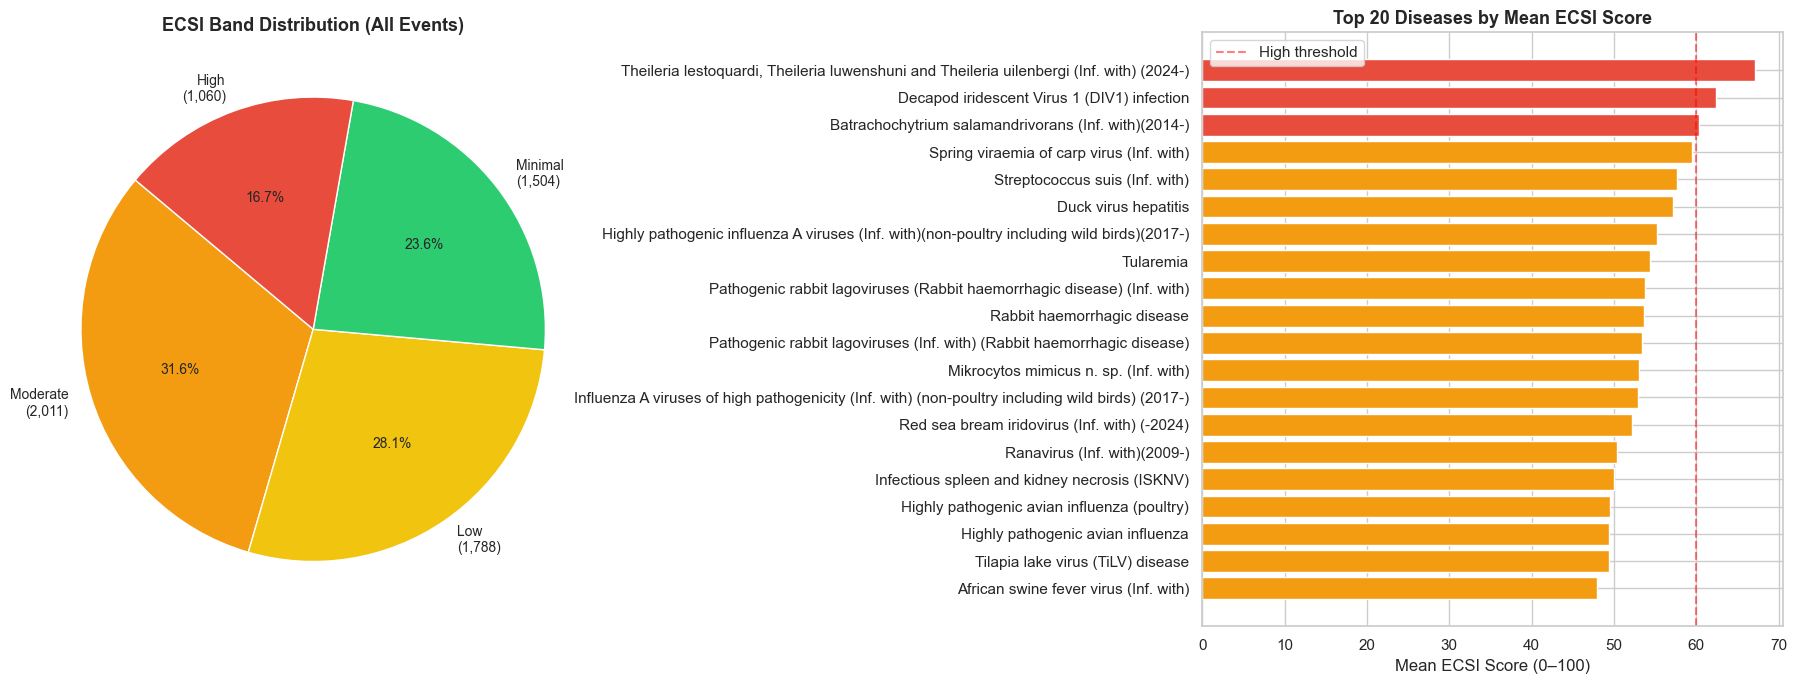

In [11]:
top_dis_ecsi = sev_profile.groupby('disease_name')['ecsi_score'].mean().nlargest(20).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
clr_map = {'Minimal':'#2ECC71','Low':'#F1C40F','Moderate':'#F39C12','High':'#E74C3C','Critical':'#8E44AD'}
band_counts = df_sev['ecsi_band'].value_counts()
axes[0].pie(band_counts.values,
            labels=[f'{b}\n({v:,})' for b,v in band_counts.items()],
            colors=[clr_map.get(b,'gray') for b in band_counts.index],
            autopct='%1.1f%%', startangle=140, textprops={'fontsize':10})
axes[0].set_title('ECSI Band Distribution (All Events)', fontsize=13, fontweight='bold')

colors_bar = [clr_map.get(ecsi_band(v),'gray') for v in top_dis_ecsi['ecsi_score']]
axes[1].barh(top_dis_ecsi['disease_name'].str.strip()[::-1],
             top_dis_ecsi['ecsi_score'][::-1], color=colors_bar[::-1])
axes[1].set_title('Top 20 Diseases by Mean ECSI Score', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mean ECSI Score (0–100)')
axes[1].axvline(60, color='red', ls='--', alpha=0.5, label='High threshold')
axes[1].legend()
plt.tight_layout(); plt.savefig('fig6_ecsi.png', dpi=150, bbox_inches='tight'); plt.show()

In [12]:
EMERGING_REASONS = [
    'Emerging disease','Unexpected change or increase','New host',
    'Listed disease occurring in a new host species','New strain',
    'New strain in the country','New strain in a zone or a compartment',
    'New pathogen strain or disease manifestation',
]
df_sev['outbreak_risk'] = (
    (df_sev['event_status'] == 'On-going') |
    (df_sev['reason_type'].isin(EMERGING_REASONS))
).astype(int)

GLOBAL_RISK_AVG = df_sev['outbreak_risk'].mean()
print(f'Target: {df_sev["outbreak_risk"].sum():,} high-risk ({GLOBAL_RISK_AVG:.1%}) | {(1-df_sev["outbreak_risk"]).sum():,} low-risk')

Target: 1,026 high-risk (16.1%) | 5,337 low-risk


In [13]:
country_risk_rate    = df_sev.groupby('country_name')['outbreak_risk'].mean().reset_index(name='country_risk_rate')
disease_risk_rate    = df_sev.groupby('disease_name')['outbreak_risk'].mean().reset_index(name='disease_risk_rate')
disease_hist_cfr     = df_sev[df_sev['cases']>0].assign(cfr=lambda d:(d['deaths']/d['cases']).clip(0,1)).groupby('disease_name')['cfr'].mean().reset_index(name='disease_hist_cfr')
disease_intervention = df_sev.groupby('disease_name')['intervention_count'].mean().reset_index(name='disease_avg_interventions')
country_vacc         = df_sev.groupby('country_name')['vaccinated'].mean().reset_index(name='country_avg_vaccinated')
country_total_events = df_sev.groupby('country_name').size().reset_index(name='country_total_events')
country_disease_ever = df_sev.groupby(['country_name','disease_name']).size().reset_index(name='times_reported_in_country')
disease_ecsi_hist    = df_sev.groupby('disease_name')['ecsi'].mean().reset_index(name='disease_hist_ecsi')

print(f'Historical tables ready | Global avg risk: {GLOBAL_RISK_AVG:.1%}')

Historical tables ready | Global avg risk: 16.1%


In [14]:
le_dict = {}
df_feat = df_sev.copy()

for col in ['country_name','disease_name','disease_group','causal_agent_type',
            'species_name','epi_unit_type','reason_type','diagnostic_method_types']:
    le = LabelEncoder()
    df_feat[col+'_enc'] = le.fit_transform(df_feat[col].fillna('Unknown').astype(str))
    le_dict[col] = le

df_feat = (
    df_feat
    .merge(country_risk_rate,    on='country_name', how='left')
    .merge(disease_risk_rate,    on='disease_name', how='left')
    .merge(disease_hist_cfr,     on='disease_name', how='left')
    .merge(disease_intervention, on='disease_name', how='left')
    .merge(country_vacc,         on='country_name', how='left')
    .merge(country_total_events, on='country_name', how='left')
    .merge(country_disease_ever, on=['country_name','disease_name'], how='left')
    .merge(disease_ecsi_hist,    on='disease_name', how='left')
)

df_feat['lat_abs']        = df_feat['latitude'].abs().fillna(30)
df_feat['is_tropical']    = (df_feat['lat_abs'] < 23.5).astype(int)
df_feat['is_temperate']   = ((df_feat['lat_abs'] >= 23.5) & (df_feat['lat_abs'] < 60)).astype(int)
df_feat['is_wild_filled'] = df_feat['is_wild'].fillna(0)
df_feat['is_winter']      = df_feat['month'].isin([12,1,2]).astype(int)
df_feat['is_summer']      = df_feat['month'].isin([6,7,8]).astype(int)
df_feat['confirm_delay']  = ((df_feat['event_confirmed_on'] - df_feat['event_started_on']).dt.days).clip(0,365).fillna(7)

for col in ['country_risk_rate','disease_risk_rate']:
    df_feat[col] = df_feat[col].fillna(GLOBAL_RISK_AVG)
for col in ['disease_hist_cfr','disease_avg_interventions','disease_hist_ecsi',
            'country_avg_vaccinated','country_total_events','times_reported_in_country']:
    df_feat[col] = df_feat[col].fillna(0)

df_feat['log_country_vacc']     = np.log1p(df_feat['country_avg_vaccinated'])
df_feat['log_country_events']   = np.log1p(df_feat['country_total_events'])
df_feat['log_times_in_country'] = np.log1p(df_feat['times_reported_in_country'])

FEATURE_COLS = [
    'country_name_enc','disease_name_enc','disease_group_enc','causal_agent_type_enc',
    'species_name_enc','epi_unit_type_enc','reason_type_enc','diagnostic_method_types_enc',
    'year','month','quarter','is_winter','is_summer',
    'lat_abs','is_tropical','is_temperate','is_domestic','is_aquatic','is_wild_filled',
    'confirm_delay','lab_test_performed','intervention_count',
    'intervention_quarantine_applied','intervention_movement_control_applied',
    'intervention_stamping_out_applied','intervention_disinfection_applied',
    'intervention_surveillance_applied','intervention_screening_applied',
    'intervention_disposal_applied','intervention_vaccination_applied',
    'intervention_zoning_applied','intervention_vector_control_applied',
    'intervention_wildlife_control_applied','intervention_traceability_applied',
    'intervention_treatment_applied','intervention_slaughter_applied',
    'country_risk_rate','disease_risk_rate','disease_hist_cfr',
    'disease_avg_interventions','log_country_vacc','log_country_events',
    'log_times_in_country','times_reported_in_country','disease_hist_ecsi',
]

X = df_feat[FEATURE_COLS].fillna(0)
y = df_feat['outbreak_risk']
print(f'Features: {X.shape[1]} | Samples: {X.shape[0]:,}')

Features: 45 | Samples: 6,363


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_tr, y_tr = SMOTE(random_state=42).fit_resample(X_train, y_train)
scaler = RobustScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc = scaler.transform(X_test)
print(f'Train (SMOTE): {X_tr.shape[0]:,} | Test: {X_test.shape[0]:,}')

Train (SMOTE): 8,538 | Test: 1,273


In [16]:
print('Random Forest...')
rf = RandomForestClassifier(n_estimators=300, max_depth=15, min_samples_leaf=5,
    max_features='sqrt', class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)
rf_pred = rf.predict(X_test); rf_prob = rf.predict_proba(X_test)[:,1]
print(f'AUC {roc_auc_score(y_test,rf_prob):.4f} | F1 {f1_score(y_test,rf_pred):.4f}')

Random Forest...
AUC 0.9734 | F1 0.8040


In [17]:
print('XGBoost...')
xgb_m = xgb.XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=8,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)
xgb_m.fit(X_tr, y_tr, eval_set=[(X_test,y_test)], verbose=False)
xgb_pred = xgb_m.predict(X_test); xgb_prob = xgb_m.predict_proba(X_test)[:,1]
print(f'AUC {roc_auc_score(y_test,xgb_prob):.4f} | F1 {f1_score(y_test,xgb_pred):.4f}')

XGBoost...
AUC 0.9843 | F1 0.8747


In [18]:
print('LightGBM...')
lgb_m = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, max_depth=10,
    num_leaves=63, subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)
lgb_m.fit(X_tr, y_tr)
lgb_pred = lgb_m.predict(X_test); lgb_prob = lgb_m.predict_proba(X_test)[:,1]
print(f'AUC {roc_auc_score(y_test,lgb_prob):.4f} | F1 {f1_score(y_test,lgb_pred):.4f}')

LightGBM...
AUC 0.9823 | F1 0.8849


In [19]:
print('Deep Neural Network...')
dnn = Sequential([
    Dense(256, activation='relu', input_shape=(X_tr_sc.shape[1],)),
    BatchNormalization(), Dropout(0.3),
    Dense(128, activation='relu'), BatchNormalization(), Dropout(0.3),
    Dense(64, activation='relu'), Dropout(0.2),
    Dense(32, activation='relu'), Dense(1, activation='sigmoid')
])
dnn.compile(optimizer=Adam(0.001), loss='binary_crossentropy',
            metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
h = dnn.fit(X_tr_sc, y_tr, validation_split=0.15, epochs=100, batch_size=256,
    callbacks=[EarlyStopping(patience=15, restore_best_weights=True, monitor='val_auc', mode='max'),
               ReduceLROnPlateau(factor=0.5, patience=7, monitor='val_auc', mode='max')], verbose=1)
dnn_prob = dnn.predict(X_te_sc).ravel(); dnn_pred = (dnn_prob>=0.5).astype(int)
print(f'AUC {roc_auc_score(y_test,dnn_prob):.4f} | F1 {f1_score(y_test,dnn_pred):.4f}')

Deep Neural Network...
Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7414 - auc: 0.8039 - loss: 0.5333 - val_accuracy: 0.7354 - val_auc: 0.0000e+00 - val_loss: 0.5733 - learning_rate: 0.0010
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8216 - auc: 0.8934 - loss: 0.3969 - val_accuracy: 0.7393 - val_auc: 0.0000e+00 - val_loss: 0.5153 - learning_rate: 0.0010
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8484 - auc: 0.9201 - loss: 0.3481 - val_accuracy: 0.8259 - val_auc: 0.0000e+00 - val_loss: 0.3960 - learning_rate: 0.0010
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8590 - auc: 0.9302 - loss: 0.3290 - val_accuracy: 0.8626 - val_auc: 0.0000e+00 - val_loss: 0.3504 - learning_rate: 0.0010
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8716 - auc: 0.9378 - loss: 0.3113 - val_accuracy: 0.8876 - val_auc: 0.0000e+00 - val_loss: 0.3000 - learning_rate: 0.0010
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s

               Accuracy      F1     AUC  AvgPrec
Model                                           
Random Forest    0.9379  0.8040  0.9734   0.9011
XGBoost          0.9615  0.8747  0.9843   0.9529
LightGBM         0.9647  0.8849  0.9823   0.9493
Deep NN          0.8209  0.5250  0.8116   0.5789
Ensemble         0.9639  0.8814  0.9818   0.9453


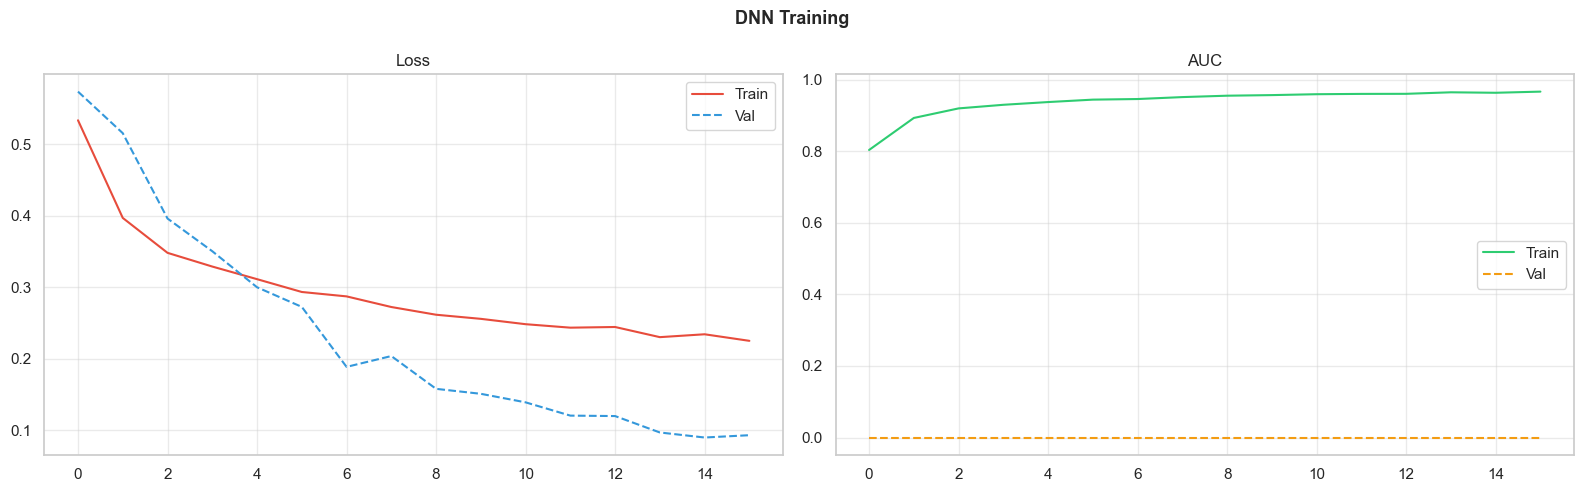

In [20]:
ens_prob = 0.25*rf_prob + 0.30*xgb_prob + 0.30*lgb_prob + 0.15*dnn_prob
ens_pred = (ens_prob>=0.5).astype(int)

MODELS = {'Random Forest':(rf_pred,rf_prob),'XGBoost':(xgb_pred,xgb_prob),
          'LightGBM':(lgb_pred,lgb_prob),'Deep NN':(dnn_pred,dnn_prob),'Ensemble':(ens_pred,ens_prob)}

results_df = pd.DataFrame([{
    'Model':n,'Accuracy':round(accuracy_score(y_test,p),4),
    'F1':round(f1_score(y_test,p),4),'AUC':round(roc_auc_score(y_test,pr),4),
    'AvgPrec':round(average_precision_score(y_test,pr),4)}
    for n,(p,pr) in MODELS.items()]).set_index('Model')
print(results_df.to_string())

fig,ax=plt.subplots(1,2,figsize=(16,5))
ax[0].plot(h.history['loss'],label='Train',color='#E74C3C'); ax[0].plot(h.history['val_loss'],label='Val',color='#3498DB',ls='--')
ax[0].set_title('Loss'); ax[0].legend(); ax[0].grid(True,alpha=0.4)
ax[1].plot(h.history['auc'],label='Train',color='#2ECC71'); ax[1].plot(h.history['val_auc'],label='Val',color='#F39C12',ls='--')
ax[1].set_title('AUC'); ax[1].legend(); ax[1].grid(True,alpha=0.4)
plt.suptitle('DNN Training',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.savefig('fig7_dnn.png',dpi=150,bbox_inches='tight'); plt.show()

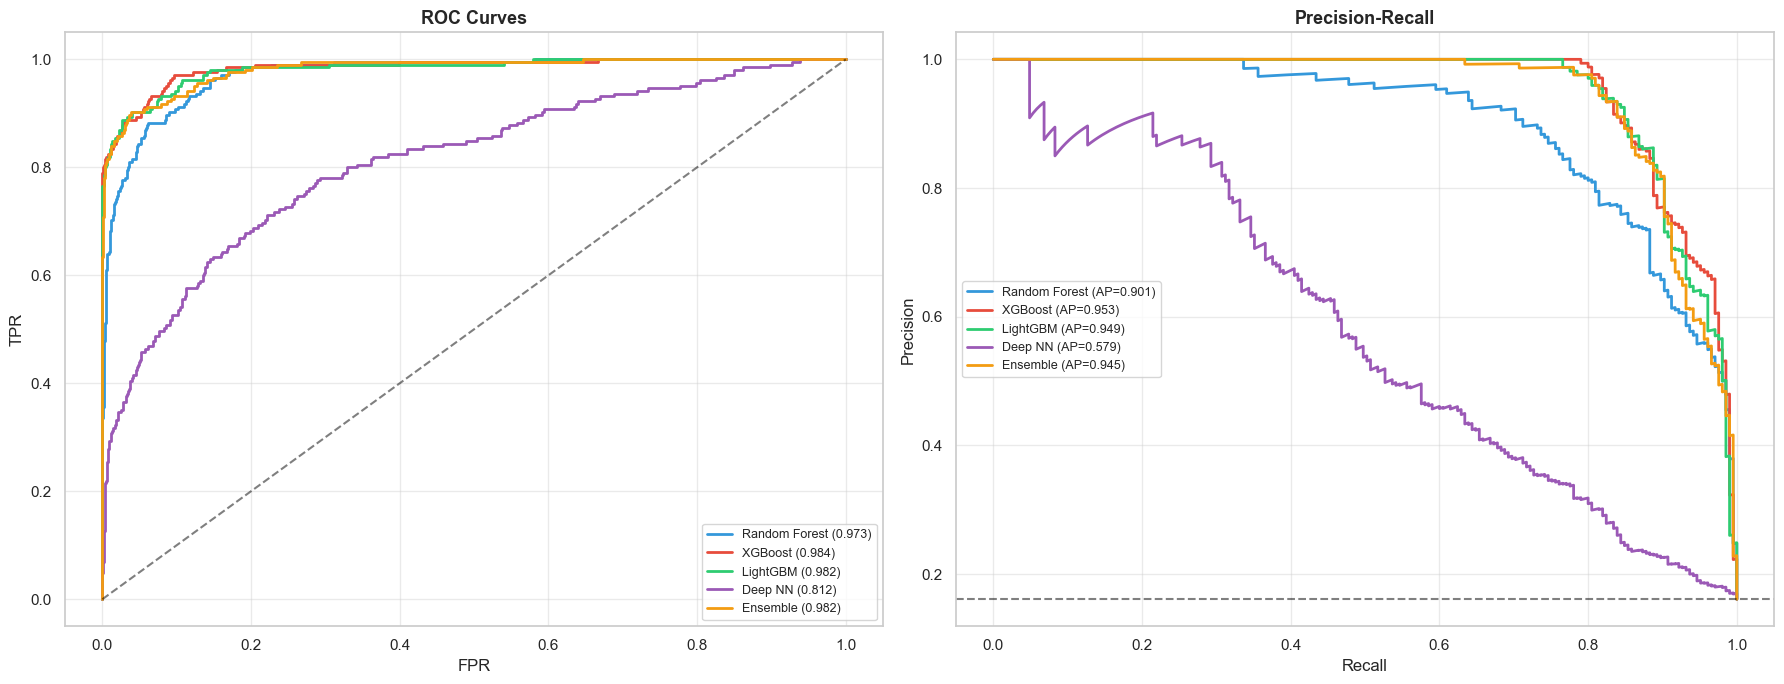

In [21]:
clrs=['#3498DB','#E74C3C','#2ECC71','#9B59B6','#F39C12']
fig,axes=plt.subplots(1,2,figsize=(18,7))
for (n,(p,pr)),c in zip(MODELS.items(),clrs):
    fpr,tpr,_=roc_curve(y_test,pr)
    axes[0].plot(fpr,tpr,label=f'{n} ({roc_auc_score(y_test,pr):.3f})',color=c,lw=2)
    prec,rec,_=precision_recall_curve(y_test,pr)
    axes[1].plot(rec,prec,label=f'{n} (AP={average_precision_score(y_test,pr):.3f})',color=c,lw=2)
axes[0].plot([0,1],[0,1],'k--',alpha=0.5); axes[0].set_title('ROC Curves',fontsize=13,fontweight='bold')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend(fontsize=9); axes[0].grid(True,alpha=0.4)
axes[1].axhline(y_test.mean(),color='k',ls='--',alpha=0.5); axes[1].set_title('Precision-Recall',fontsize=13,fontweight='bold')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].legend(fontsize=9); axes[1].grid(True,alpha=0.4)
plt.tight_layout(); plt.savefig('fig8_roc.png',dpi=150,bbox_inches='tight'); plt.show()

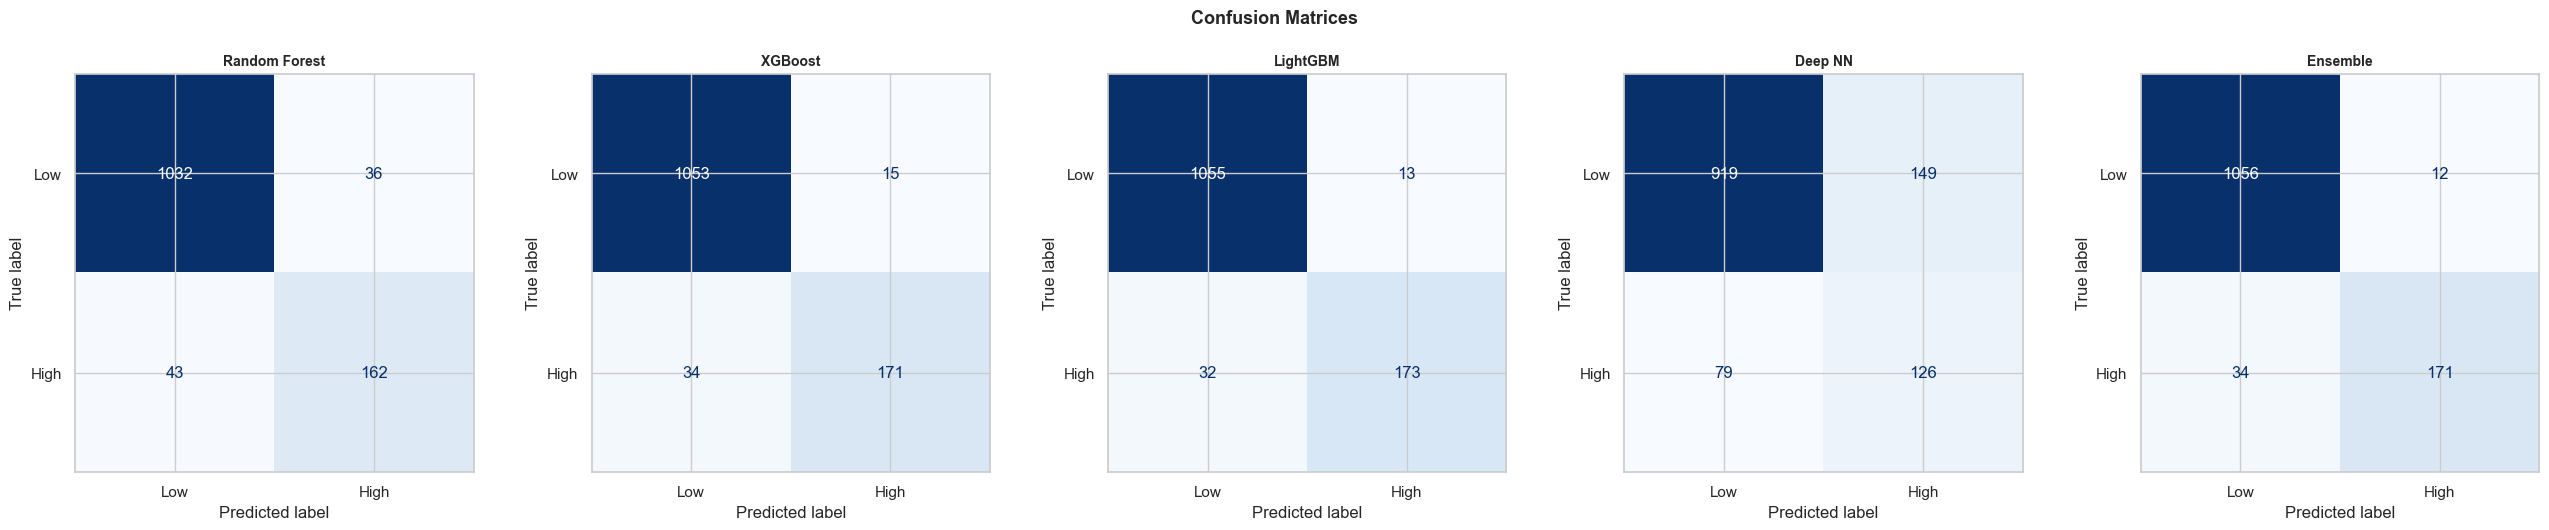

In [22]:
fig,axes=plt.subplots(1,5,figsize=(26,5))
for ax,(n,(p,_)) in zip(axes,MODELS.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test,p),display_labels=['Low','High']).plot(ax=ax,colorbar=False,cmap='Blues')
    ax.set_title(n.replace('🏆 ',''),fontsize=10,fontweight='bold')
plt.suptitle('Confusion Matrices',fontsize=13,fontweight='bold',y=1.02)
plt.tight_layout(); plt.savefig('fig9_confusion.png',dpi=150,bbox_inches='tight'); plt.show()

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0021 - mae: 0.0331 - val_loss: 0.0530 - val_mae: 0.1291
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0021 - mae: 0.0327 - val_loss: 0.0434 - val_mae: 0.1242
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0018 - mae: 0.0308 - val_loss: 0.0384 - val_mae: 0.1232
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0018 - mae: 0.0301 - val_loss: 0.0363 - val_mae: 0.1172
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0016 - mae: 0.0295 - val_loss: 0.0407 - val_mae: 0.1105
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0016 - mae: 0.0295 - val_loss: 0.0382 - val_mae: 0.1107
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0015 - mae: 0.0280 - val_loss: 0.0338 - val_mae: 0.1044
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0014 - mae: 0.0256 - val_loss: 0.0342 - val_mae: 0.1022
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.00

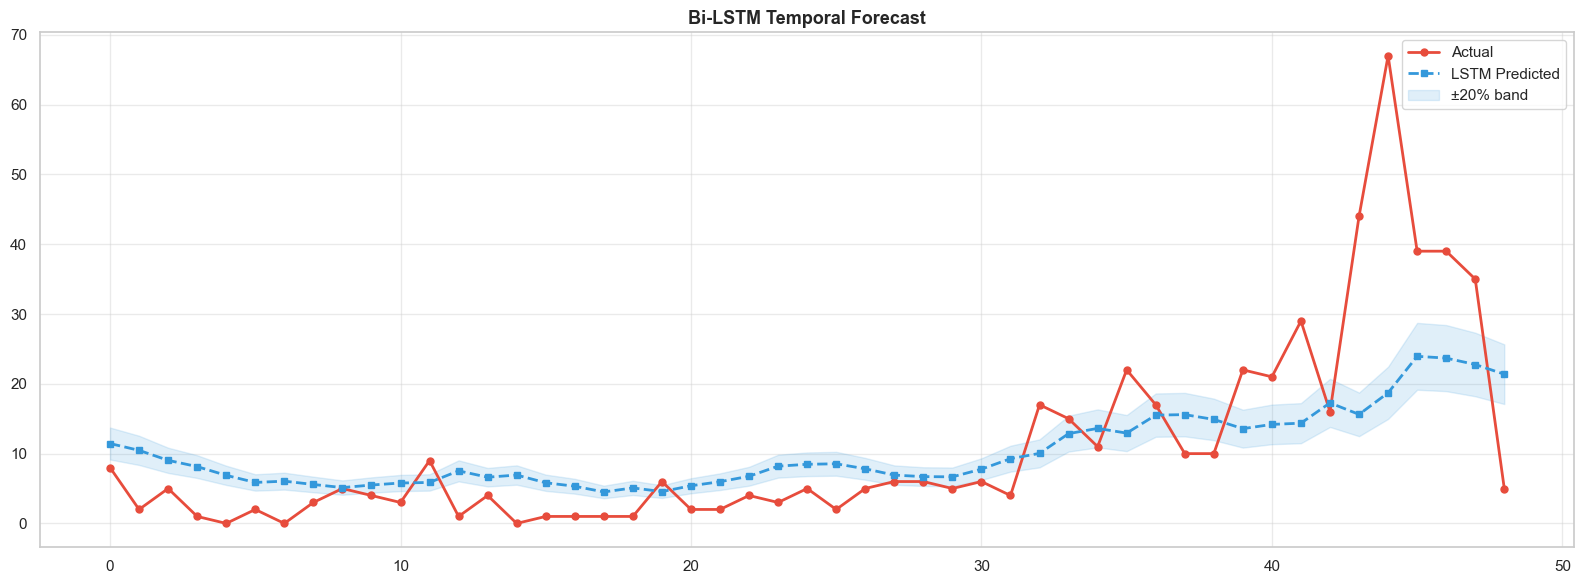

In [23]:
ts = df_feat.dropna(subset=['year','month']).copy()
ts['period'] = ts['year'].astype(int).astype(str)+'-'+ts['month'].astype(int).astype(str).str.zfill(2)
mts = ts.groupby('period').agg(outbreak_count=('outbreak_risk','sum'),
    total_events=('event_id','count'), avg_cfr=('disease_hist_cfr','mean'),
    avg_ecsi=('disease_hist_ecsi','mean')).reset_index().sort_values('period').reset_index(drop=True)
lsc = MinMaxScaler(); lf=['outbreak_count','total_events','avg_cfr','avg_ecsi']
sd = lsc.fit_transform(mts[lf]); LB=12
def mkseq(d,lb): return np.array([d[i:i+lb] for i in range(len(d)-lb)]), np.array([d[i+lb,0] for i in range(len(d)-lb)])
Xs,ys=mkseq(sd,LB); sp=int(len(Xs)*0.8)
lstm_m = Sequential([Bidirectional(LSTM(64,return_sequences=True),input_shape=(LB,len(lf))),
    Dropout(0.2),LSTM(32),Dropout(0.2),Dense(16,activation='relu'),Dense(1)])
lstm_m.compile(optimizer=Adam(0.001),loss='mse',metrics=['mae'])
lstm_m.fit(Xs[:sp],ys[:sp],epochs=100,batch_size=16,validation_data=(Xs[sp:],ys[sp:]),
    callbacks=[EarlyStopping(patience=15,restore_best_weights=True)],verbose=1)
yps=lstm_m.predict(Xs[sp:]).ravel()
def inv(v): d=np.zeros((len(v),len(lf))); d[:,0]=v; return lsc.inverse_transform(d)[:,0]
act=inv(ys[sp:]); prd=inv(yps)
fig,ax=plt.subplots(figsize=(16,6))
ax.plot(act,label='Actual',color='#E74C3C',lw=2,marker='o',ms=5)
ax.plot(prd,label='LSTM Predicted',color='#3498DB',lw=2,ls='--',marker='s',ms=5)
ax.fill_between(range(len(act)),prd*0.8,prd*1.2,alpha=0.15,color='#3498DB',label='±20% band')
ax.set_title('Bi-LSTM Temporal Forecast',fontsize=13,fontweight='bold'); ax.legend(); ax.grid(True,alpha=0.4)
plt.tight_layout(); plt.savefig('fig10_lstm.png',dpi=150,bbox_inches='tight'); plt.show()

SHAP values...


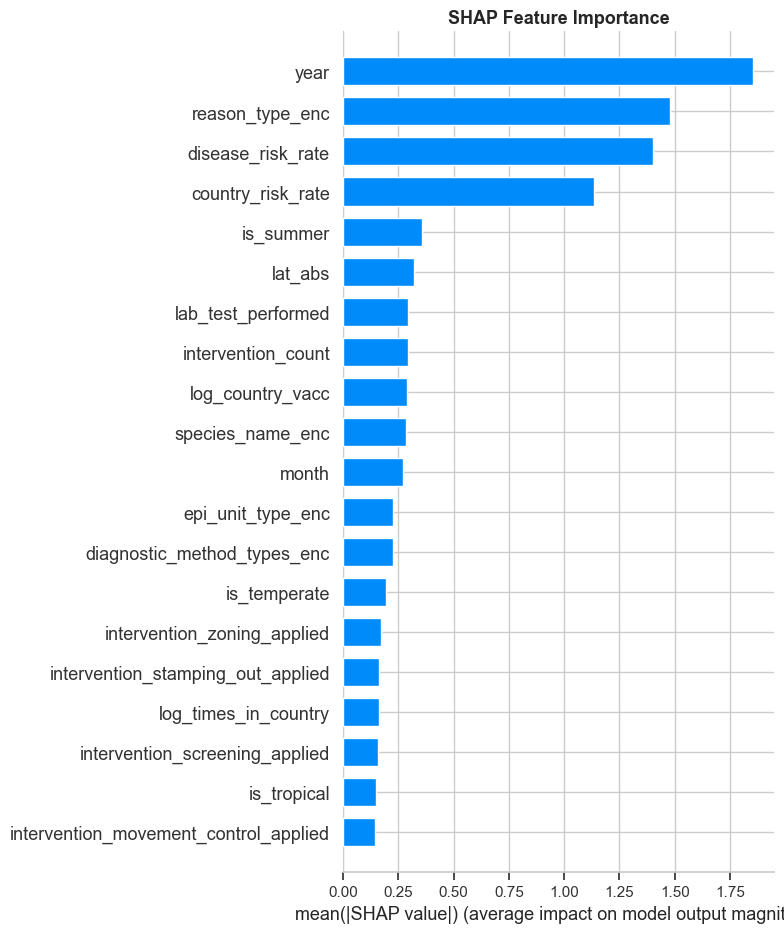

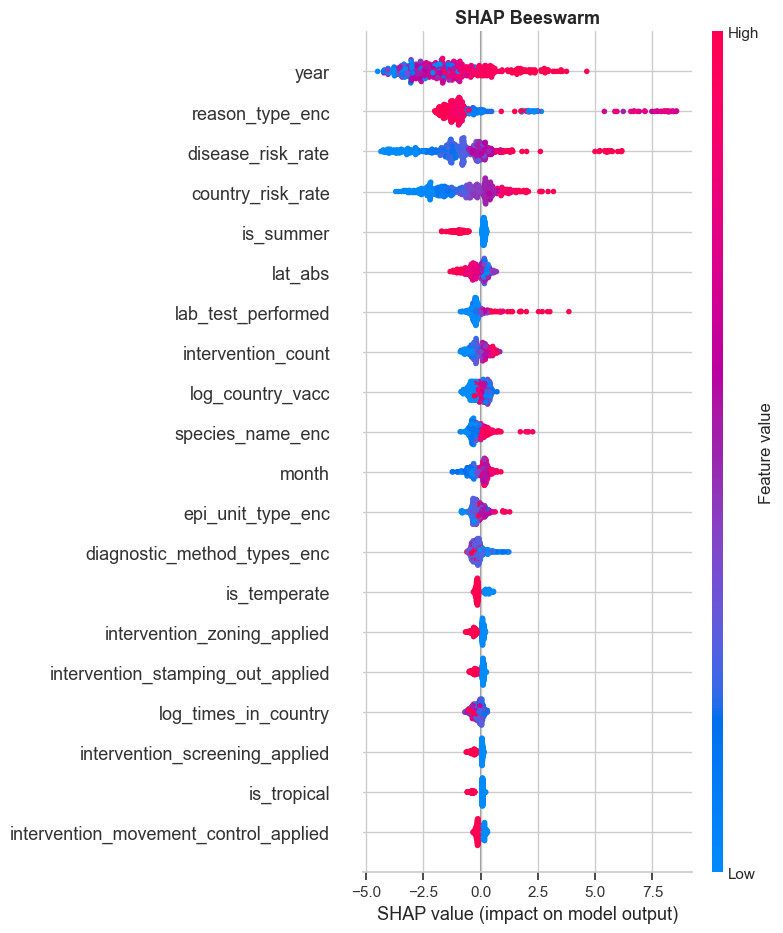

In [24]:
print('SHAP values...')
exp=shap.TreeExplainer(xgb_m); Xs2=X_test.sample(min(500,len(X_test)),random_state=42); sv=exp.shap_values(Xs2)
plt.figure(figsize=(12,9))
shap.summary_plot(sv,Xs2,feature_names=FEATURE_COLS,plot_type='bar',show=False,max_display=20)
plt.title('SHAP Feature Importance',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.savefig('fig11_shap.png',dpi=150,bbox_inches='tight'); plt.show()

plt.figure(figsize=(14,10))
shap.summary_plot(sv,Xs2,feature_names=FEATURE_COLS,show=False,max_display=20)
plt.title('SHAP Beeswarm',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.savefig('fig12_shap_bee.png',dpi=150,bbox_inches='tight'); plt.show()

In [25]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

print('Building cascading lookup maps...')

CTY_DIS = df_raw.groupby('country_name')['disease_name'].apply(
    lambda x: sorted(x.dropna().unique().tolist())).to_dict()

CTY_DIS_SP = df_raw.groupby(['country_name','disease_name'])['species_name'].apply(
    lambda x: sorted(x.dropna().unique().tolist())).to_dict()

CTY_DIS_EPI = df_raw.groupby(['country_name','disease_name'])['epi_unit_type'].apply(
    lambda x: sorted(x.dropna().unique().tolist())).to_dict()

CTY_DIS_REASON = df_raw.groupby(['country_name','disease_name'])['reason_type'].apply(
    lambda x: sorted(x.dropna().unique().tolist())).to_dict()

CTY_DIS_DIAG = df_raw.groupby(['country_name','disease_name'])['diagnostic_method_types'].apply(
    lambda x: sorted(x.dropna().unique().tolist())).to_dict()

def safe_mode(x):
    v = x.dropna()
    return v.value_counts().index[0] if len(v) > 0 else 'Unknown'

CTY_DIS_GRP = df_raw.groupby(['country_name','disease_name'])['disease_group'].agg(safe_mode).to_dict()
CTY_DIS_AGT = df_raw.groupby(['country_name','disease_name'])['causal_agent_type'].agg(safe_mode).to_dict()
CTY_LAT     = df_raw.dropna(subset=['latitude']).groupby('country_name')['latitude'].mean().round(2).to_dict()
CTY_DIS_DOM = df_raw.groupby(['country_name','disease_name'])['is_domestic'].mean().to_dict()
CTY_DIS_AQT = df_raw.groupby(['country_name','disease_name'])['is_aquatic'].mean().to_dict()

_c_risk  = country_risk_rate.set_index('country_name')['country_risk_rate'].to_dict()
_d_risk  = disease_risk_rate.set_index('disease_name')['disease_risk_rate'].to_dict()
_d_cfr   = disease_hist_cfr.set_index('disease_name')['disease_hist_cfr'].to_dict()
_d_intv  = disease_intervention.set_index('disease_name')['disease_avg_interventions'].to_dict()
_c_vacc  = country_vacc.set_index('country_name')['country_avg_vaccinated'].to_dict()
_c_tot   = country_total_events.set_index('country_name')['country_total_events'].to_dict()
_cd_occ  = country_disease_ever.set_index(['country_name','disease_name'])['times_reported_in_country'].to_dict()
_d_ecsi  = disease_ecsi_hist.set_index('disease_name')['disease_hist_ecsi'].to_dict()

ALL_COUNTRIES = sorted(df_raw['country_name'].dropna().unique().tolist())

INT_MAP = {
    'Quarantine':                'intervention_quarantine_applied',
    'Movement Control':          'intervention_movement_control_applied',
    'Stamping Out (Culling)':    'intervention_stamping_out_applied',
    'Disinfection':              'intervention_disinfection_applied',
    'Surveillance':              'intervention_surveillance_applied',
    'Screening':                 'intervention_screening_applied',
    'Safe Disposal':             'intervention_disposal_applied',
    'Vaccination Campaign':      'intervention_vaccination_applied',
    'Zoning / Regionalization':  'intervention_zoning_applied',
    'Vector Control':            'intervention_vector_control_applied',
    'Wildlife Control':          'intervention_wildlife_control_applied',
    'Animal Traceability':       'intervention_traceability_applied',
    'Medical Treatment':         'intervention_treatment_applied',
    'Preventive Slaughter':      'intervention_slaughter_applied',
}

INT_DESC = {
    'Quarantine':                'Isolating infected animals/premises to prevent spread',
    'Movement Control':          'Restricting animal transport between zones/regions',
    'Stamping Out (Culling)':    'Killing infected/exposed animals to eliminate the disease',
    'Disinfection':              'Cleaning and decontaminating affected premises',
    'Surveillance':              'Enhanced monitoring and case-finding in surrounding areas',
    'Screening':                 'Testing programs to identify sub-clinical infections',
    'Safe Disposal':             'Proper disposal of carcasses to prevent environmental spread',
    'Vaccination Campaign':      'Immunization of susceptible animals or at-risk populations',
    'Zoning / Regionalization':  'Establishing infected / buffer / free zones',
    'Vector Control':            'Controlling insect / arthropod disease vectors',
    'Wildlife Control':          'Managing wild animal reservoir hosts',
    'Animal Traceability':       'Tracking animal movements and contacts for tracing',
    'Medical Treatment':         'Therapeutic treatment of infected animals',
    'Preventive Slaughter':      'Slaughter of at-risk animals as a precautionary measure',
}

print(f'Cascading maps ready')
print(f'Countries: {len(ALL_COUNTRIES)}')
print(f'Country-Disease combos: {len(CTY_DIS_GRP):,}')

Building cascading lookup maps...
Cascading maps ready
Countries: 194
Country-Disease combos: 2,022


In [26]:
def make_prediction(country, disease, disease_group, causal_agent, species,
                    epi_unit, reason_type, diag_method, month, year, latitude,
                    confirm_delay, is_domestic, is_aquatic, is_wild,
                    lab_tests, selected_ints):

    def enc(col, val):
        le = le_dict.get(col)
        if le is None: return 0
        s = str(val)
        return int(le.transform([s])[0]) if s in le.classes_ else 0

    int_flags = {v: (1 if k in selected_ints else 0) for k, v in INT_MAP.items()}
    times_in_country = float(_cd_occ.get((country, disease), 0.0))
    lat_abs = abs(latitude)

    row = {
        'country_name_enc':            enc('country_name', country),
        'disease_name_enc':            enc('disease_name', disease),
        'disease_group_enc':           enc('disease_group', disease_group),
        'causal_agent_type_enc':       enc('causal_agent_type', causal_agent),
        'species_name_enc':            enc('species_name', species),
        'epi_unit_type_enc':           enc('epi_unit_type', epi_unit),
        'reason_type_enc':             enc('reason_type', reason_type),
        'diagnostic_method_types_enc': enc('diagnostic_method_types', diag_method),
        'year': year, 'month': month, 'quarter': (month-1)//3+1,
        'is_winter': int(month in [12,1,2]), 'is_summer': int(month in [6,7,8]),
        'lat_abs': lat_abs, 'is_tropical': int(lat_abs < 23.5),
        'is_temperate': int(23.5 <= lat_abs < 60),
        'is_domestic': int(is_domestic), 'is_aquatic': int(is_aquatic),
        'is_wild_filled': int(is_wild),
        'confirm_delay': confirm_delay, 'lab_test_performed': lab_tests,
        'intervention_count': len(selected_ints),
        'country_risk_rate':         _c_risk.get(country, GLOBAL_RISK_AVG),
        'disease_risk_rate':         _d_risk.get(disease, GLOBAL_RISK_AVG),
        'disease_hist_cfr':          _d_cfr.get(disease, 0.0),
        'disease_avg_interventions': _d_intv.get(disease, 0.0),
        'log_country_vacc':          np.log1p(_c_vacc.get(country, 0)),
        'log_country_events':        np.log1p(_c_tot.get(country, 0)),
        'log_times_in_country':      np.log1p(times_in_country),
        'times_reported_in_country': times_in_country,
        'disease_hist_ecsi':         _d_ecsi.get(disease, 0.0),
        **int_flags
    }

    X_in    = pd.DataFrame([row])[FEATURE_COLS].fillna(0)
    X_in_sc = scaler.transform(X_in)

    p_rf  = float(rf.predict_proba(X_in)[:,1][0])
    p_xgb = float(xgb_m.predict_proba(X_in)[:,1][0])
    p_lgb = float(lgb_m.predict_proba(X_in)[:,1][0])
    p_dnn = float(dnn.predict(X_in_sc, verbose=0).ravel()[0])
    p_ens = 0.25*p_rf + 0.30*p_xgb + 0.30*p_lgb + 0.15*p_dnn

    prof = sev_profile_dict.get((country, disease), {})
    ecsi = prof.get('ecsi_score', _d_ecsi.get(disease, 0.0))
    ecsi_b = ecsi_band(ecsi)

    govt_measures = []
    for label, col in INT_MAP.items():
        usage = prof.get(col, 0.0)
        if usage > 0.3:
            govt_measures.append((label, usage))
    govt_measures.sort(key=lambda x: -x[1])

    return {
        'ensemble': round(p_ens, 4),
        'models': {'Random Forest': p_rf, 'XGBoost': p_xgb, 'LightGBM': p_lgb, 'Deep NN': p_dnn},
        'times_in_country': times_in_country,
        'country_base': _c_risk.get(country, GLOBAL_RISK_AVG),
        'disease_global': _d_risk.get(disease, GLOBAL_RISK_AVG),
        'ecsi': ecsi, 'ecsi_band': ecsi_b,
        'profile': prof,
        'govt_measures': govt_measures,
    }

print('Prediction engine ready')

Prediction engine ready


In [27]:
from IPython.display import display, HTML, clear_output

display(HTML('''
<div style="background:linear-gradient(135deg,#1a1a2e,#16213e,#0f3460);
            color:white;padding:22px 26px;border-radius:14px;margin-bottom:16px;">
  <h2 style="margin:0;font-size:24px;">Animal Disease Outbreak Predictor</h2>
  <p style="margin:8px 0 0 0;opacity:0.8;font-size:13px;line-height:1.6;">
    <b>Smart cascading dropdowns</b> — select a country and only diseases reported
    in that region appear. Select a disease and species/location/reason auto-filter.
    Output includes <b>ECSI severity score</b> and <b>historical government measures</b>.
  </p>
</div>
'''))

S = {'description_width': '175px'}
L = widgets.Layout(width='460px')
Ls = widgets.Layout(width='220px')
MNAMES = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

init_country  = 'Germany'
init_diseases = CTY_DIS.get(init_country, ['Unknown'])
init_disease  = init_diseases[0]
init_species  = CTY_DIS_SP.get((init_country, init_disease), ['Unknown'])
init_epi      = CTY_DIS_EPI.get((init_country, init_disease), ['Farm'])
init_reasons  = CTY_DIS_REASON.get((init_country, init_disease), ['Recurrence'])
init_diag     = CTY_DIS_DIAG.get((init_country, init_disease), ['Diagnostic test'])

w_country = widgets.Dropdown(options=ALL_COUNTRIES, value=init_country,
                              description='Country:', style=S, layout=L)
w_disease = widgets.Dropdown(options=init_diseases, value=init_disease,
                              description='Disease:', style=S, layout=L)
w_dgroup  = widgets.Text(value=CTY_DIS_GRP.get((init_country,init_disease),'Unknown'),
                          description='Disease Group:', style=S, layout=L, disabled=True)
w_agent   = widgets.Text(value=CTY_DIS_AGT.get((init_country,init_disease),'Unknown'),
                          description='Causal Agent:', style=S, layout=L, disabled=True)
w_species = widgets.Dropdown(options=init_species, value=init_species[0],
                              description='Species:', style=S, layout=L)
w_epi     = widgets.Dropdown(options=init_epi, value=init_epi[0],
                              description='Epi Unit Type:', style=S, layout=L)
w_reason  = widgets.Dropdown(options=init_reasons, value=init_reasons[0],
                              description='Reason Type:', style=S, layout=L)
w_diag    = widgets.Dropdown(options=init_diag, value=init_diag[0],
                              description='Diagnostic Method:', style=S, layout=L)
w_lat     = widgets.FloatSlider(value=float(CTY_LAT.get(init_country, 51.0)),
                                 min=-90, max=90, step=0.5, description='Latitude (auto):',
                                 style=S, layout=L, readout_format='.1f')
w_month   = widgets.Dropdown(options=[(m,i) for i,m in enumerate(MNAMES,1)], value=1,
                              description='Month:', style=S, layout=Ls)
w_year    = widgets.IntSlider(value=2025, min=2005, max=2030, description='Year:', style=S, layout=L)
w_delay   = widgets.IntSlider(value=3, min=0, max=90, description='Confirm Delay (d):', style=S, layout=L)
w_lab     = widgets.IntText(value=10, description='Lab Tests:', style=S, layout=Ls)
w_dom = widgets.ToggleButton(value=True,  description='Domestic', button_style='info')
w_aqt = widgets.ToggleButton(value=False, description='Aquatic',  button_style='info')
w_wld = widgets.ToggleButton(value=False, description='Wild',     button_style='info')
w_ints = widgets.SelectMultiple(options=list(INT_MAP.keys()),
    value=['Quarantine','Surveillance'], layout=widgets.Layout(width='460px', height='195px'))

btn = widgets.Button(description='PREDICT OUTBREAK RISK',
    button_style='danger', layout=widgets.Layout(width='460px', height='52px'))
out = widgets.Output()

def update_disease_list(change):
    """When country changes: update disease dropdown to only show diseases in that country"""
    c = change['new']
    diseases = CTY_DIS.get(c, ['Unknown'])
    w_disease.options = diseases
    w_disease.value   = diseases[0] if diseases else 'Unknown'
    w_lat.value = float(CTY_LAT.get(c, 0.0))

def update_sub_fields(change):
    """When disease changes: update species, epi, reason, diag, group, agent"""
    c = w_country.value
    d = change['new']
    key = (c, d)

    sp_list = CTY_DIS_SP.get(key, ['Unknown'])
    w_species.options = sp_list
    w_species.value   = sp_list[0] if sp_list else 'Unknown'

    ep_list = CTY_DIS_EPI.get(key, ['Farm'])
    w_epi.options = ep_list
    w_epi.value   = ep_list[0] if ep_list else 'Farm'

    re_list = CTY_DIS_REASON.get(key, ['Recurrence'])
    w_reason.options = re_list
    w_reason.value   = re_list[0] if re_list else 'Recurrence'

    di_list = CTY_DIS_DIAG.get(key, ['Diagnostic test'])
    w_diag.options = di_list
    w_diag.value   = di_list[0] if di_list else 'Diagnostic test'

    w_dgroup.value = CTY_DIS_GRP.get(key, 'Unknown')
    w_agent.value  = CTY_DIS_AGT.get(key, 'Unknown')

    dom_val = CTY_DIS_DOM.get(key, 0.5)
    aqt_val = CTY_DIS_AQT.get(key, 0.0)
    w_dom.value = bool(dom_val >= 0.5)
    w_aqt.value = bool(aqt_val >= 0.5)

w_country.observe(update_disease_list, names='value')
w_disease.observe(update_sub_fields,   names='value')

def on_click(b):
    with out:
        clear_output(wait=True)

        res = make_prediction(
            country=w_country.value, disease=w_disease.value,
            disease_group=w_dgroup.value, causal_agent=w_agent.value,
            species=w_species.value, epi_unit=w_epi.value,
            reason_type=w_reason.value, diag_method=w_diag.value,
            month=w_month.value, year=w_year.value, latitude=w_lat.value,
            confirm_delay=w_delay.value, is_domestic=w_dom.value,
            is_aquatic=w_aqt.value, is_wild=w_wld.value,
            lab_tests=w_lab.value, selected_ints=list(w_ints.value)
        )

        prob  = res['ensemble']
        ecsi  = res['ecsi']
        ecsi_b= res['ecsi_band']
        prof  = res['profile']
        govt  = res['govt_measures']
        times = int(res['times_in_country'])

        if prob >= 0.70:   p_clr='#C0392B'; p_bg='#FDEDEC'; p_lv='🔴 CRITICAL'
        elif prob >= 0.50: p_clr='#D35400'; p_bg='#FEF5E7'; p_lv='🟠 HIGH'
        elif prob >= 0.30: p_clr='#B7950B'; p_bg='#FEFDE7'; p_lv='🟡 MODERATE'
        else:              p_clr='#1E8449'; p_bg='#EAFAF1'; p_lv='🟢 LOW'

        ECSI_COLORS = {'Minimal':'#27AE60','Low':'#F1C40F','Moderate':'#F39C12','High':'#E74C3C','Critical':'#8E44AD'}
        e_clr = ECSI_COLORS.get(ecsi_b, '#7F8C8D')

        occ_msg = f'First occurrence ever in {w_country.value}' if times == 0 else f'Reported {times}× previously in {w_country.value}'

        display(HTML(f'''
        <div style="display:flex;gap:14px;margin:10px 0;">
          <div style="flex:1;background:{p_bg};border-left:7px solid {p_clr};
                      border-radius:10px;padding:16px 20px;">
            <div style="font-size:12px;color:#7f8c8d;text-transform:uppercase;letter-spacing:1px;">Outbreak Probability</div>
            <div style="font-size:44px;font-weight:900;color:{p_clr};margin:4px 0;">{prob:.1%}</div>
            <div style="font-size:18px;font-weight:bold;color:{p_clr};">{p_lv} RISK</div>
            <div style="font-size:12px;color:#555;margin-top:8px;">{occ_msg}</div>
          </div>
          <div style="flex:1;background:#F8F9FA;border-left:7px solid {e_clr};
                      border-radius:10px;padding:16px 20px;">
            <div style="font-size:12px;color:#7f8c8d;text-transform:uppercase;letter-spacing:1px;">Epidemiological Severity (ECSI)</div>
            <div style="font-size:44px;font-weight:900;color:{e_clr};margin:4px 0;">{ecsi:.1f}<span style="font-size:18px">/100</span></div>
            <div style="font-size:18px;font-weight:bold;color:{e_clr};">{ecsi_b.upper()} SEVERITY</div>
            <div style="font-size:12px;color:#555;margin-top:8px;">
              CFR: {prof.get("avg_cfr",0):.1%} &nbsp;·&nbsp;
              Attack Rate: {prof.get("avg_attack_rate",0):.1%} &nbsp;·&nbsp;
              Recurrence: {prof.get("recurrence_rate",0):.1%}
            </div>
          </div>
          <div style="flex:1;background:#EBF5FB;border-left:7px solid #2980B9;
                      border-radius:10px;padding:16px 20px;">
            <div style="font-size:12px;color:#7f8c8d;text-transform:uppercase;letter-spacing:1px;">Disease Profile</div>
            <div style="font-size:14px;font-weight:bold;color:#2c3e50;margin-top:6px;">{w_disease.value.strip()}</div>
            <div style="font-size:12px;color:#555;margin-top:6px;line-height:1.8;">
              Country: <b>{w_country.value}</b><br>
              Agent: <b>{w_agent.value}</b> &nbsp;|&nbsp; Group: <b>{w_dgroup.value}</b><br>
              Period: <b>{MNAMES[w_month.value-1]} {w_year.value}</b><br>
              Total events on record: <b>{int(prof.get("total_events",0))}</b>
            </div>
          </div>
        </div>
        '''))

        fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
        fig.patch.set_facecolor('#FAFAFA')

        ax1=axes[0]; ax1.set_facecolor('#FAFAFA'); ax1.axis('off')
        theta=np.linspace(np.pi,0,300)
        ax1.plot(np.cos(theta),np.sin(theta),color='#ECF0F1',linewidth=20,solid_capstyle='round')
        ea=np.pi-prob*np.pi; tf2=np.linspace(np.pi,ea,300)
        ax1.plot(np.cos(tf2),np.sin(tf2),color=p_clr,linewidth=20,solid_capstyle='round')
        for thr,tc,tl in [(0.3,'#B7950B','30%'),(0.5,'#D35400','50%'),(0.7,'#C0392B','70%')]:
            a=np.pi-thr*np.pi
            ax1.plot([0.80*np.cos(a),1.00*np.cos(a)],[0.80*np.sin(a),1.00*np.sin(a)],color=tc,lw=2)
            ax1.text(1.18*np.cos(a),1.18*np.sin(a),tl,ha='center',va='center',fontsize=8,color=tc,fontweight='bold')
        ax1.text(0,0.22,f'{prob:.1%}',ha='center',va='center',fontsize=22,fontweight='bold',color=p_clr)
        ax1.text(0,-0.02,f'{p_lv} RISK',ha='center',fontsize=10,fontweight='bold',color=p_clr)
        ax1.set_xlim(-1.4,1.4); ax1.set_ylim(-0.45,1.3); ax1.set_title('Outbreak Risk',fontsize=11,fontweight='bold',pad=4)

        ax2 = axes[1]; ax2.set_facecolor('#FAFAFA')
        comp_labels = ['CFR\n(w=0.30)', 'Attack\nRate\n(w=0.25)', 'Kill\nRatio\n(w=0.15)',
                       'Duration\n(w=0.10)', 'Emerging\n(w=0.12)', 'Recurrence\n(w=0.08)']
        raw_vals = [prof.get('avg_cfr',0), prof.get('avg_attack_rate',0),
                    min(prof.get('avg_kill_ratio',0)/5.0,1.0),
                    min(prof.get('avg_duration_days',0)/730.0,1.0),
                    prof.get('emerging_rate',0), prof.get('recurrence_rate',0)]
        weights = [W_CFR, W_AR, W_KR, W_DUR, W_EMERG, W_RECUR]
        contrib = [v*w*100 for v,w in zip(raw_vals, weights)]
        bar_c = [ECSI_COLORS.get(ecsi_band(c*100/w if w>0 else 0), '#3498DB') for c,w in zip(contrib,weights)]
        b2 = ax2.bar(comp_labels, contrib, color=['#E74C3C','#E67E22','#F39C12','#3498DB','#9B59B6','#1ABC9C'],
                     edgecolor='white', width=0.6)
        ax2.set_title(f'ECSI Components (Total = {ecsi:.1f})', fontsize=11, fontweight='bold')
        ax2.set_ylabel('Weighted Contribution to ECSI')
        ax2.grid(True, alpha=0.3, axis='y')
        for bar, v in zip(b2, contrib):
            if v > 0.5: ax2.text(bar.get_x()+bar.get_width()/2, v+0.2, f'{v:.1f}',
                                  ha='center', fontsize=9, fontweight='bold')

        ax3=axes[2]; ax3.set_facecolor('#FAFAFA')
        mn=list(res['models'].keys()); mv=list(res['models'].values())
        bars=ax3.barh(mn,mv,color=['#3498DB','#E74C3C','#2ECC71','#9B59B6'],edgecolor='white',height=0.55)
        ax3.axvline(0.5,color='#C0392B',linestyle='--',lw=2,alpha=0.8,label='Decision boundary')
        ax3.set_xlim(0,1.05)
        for bar,v in zip(bars,mv):
            ax3.text(min(v+0.02,1.0),bar.get_y()+bar.get_height()/2,f'{v:.1%}',va='center',fontsize=10,fontweight='bold')
        ax3.set_title('Model Probabilities',fontsize=11,fontweight='bold')
        ax3.set_xlabel('Probability'); ax3.legend(fontsize=8); ax3.grid(True,alpha=0.3,axis='x')

        plt.suptitle(f'{w_disease.value.strip()} · {w_country.value}',
                     fontsize=12, fontweight='bold', y=1.01)
        plt.tight_layout(); plt.show()

        display(HTML(f'''
        <div style="background:#F8F9FA;border-radius:10px;padding:16px 20px;margin:10px 0;">
          <div style="font-size:14px;font-weight:bold;color:#2c3e50;margin-bottom:10px;">Epidemiological Severity Breakdown</div>
          <table style="width:100%;border-collapse:collapse;font-size:13px;">
            <tr style="background:#2c3e50;color:white;">
              <th style="padding:8px 12px;text-align:left;">Component</th>
              <th style="padding:8px 12px;text-align:center;">Raw Value</th>
              <th style="padding:8px 12px;text-align:center;">Weight</th>
              <th style="padding:8px 12px;text-align:center;">Contribution</th>
              <th style="padding:8px 12px;text-align:left;">Bar</th>
            </tr>
            <tr style="background:white;">
              <td style="padding:7px 12px;">Case Fatality Rate (CFR)</td>
              <td style="padding:7px 12px;text-align:center;"><b>{prof.get("avg_cfr",0):.1%}</b></td>
              <td style="padding:7px 12px;text-align:center;">0.30</td>
              <td style="padding:7px 12px;text-align:center;">{contrib[0]:.2f}</td>
              <td style="padding:7px 12px;"><div style="background:#E74C3C;height:12px;width:{min(contrib[0]*4,100):.0f}%;border-radius:3px;"></div></td>
            </tr>
            <tr style="background:#F9F9F9;">
              <td style="padding:7px 12px;">Attack Rate</td>
              <td style="padding:7px 12px;text-align:center;"><b>{prof.get("avg_attack_rate",0):.1%}</b></td>
              <td style="padding:7px 12px;text-align:center;">0.25</td>
              <td style="padding:7px 12px;text-align:center;">{contrib[1]:.2f}</td>
              <td style="padding:7px 12px;"><div style="background:#E67E22;height:12px;width:{min(contrib[1]*4,100):.0f}%;border-radius:3px;"></div></td>
            </tr>
            <tr style="background:white;">
              <td style="padding:7px 12px;">Kill Ratio</td>
              <td style="padding:7px 12px;text-align:center;"><b>{prof.get("avg_kill_ratio",0):.2f}</b></td>
              <td style="padding:7px 12px;text-align:center;">0.15</td>
              <td style="padding:7px 12px;text-align:center;">{contrib[2]:.2f}</td>
              <td style="padding:7px 12px;"><div style="background:#F39C12;height:12px;width:{min(contrib[2]*4,100):.0f}%;border-radius:3px;"></div></td>
            </tr>
            <tr style="background:#F9F9F9;">
              <td style="padding:7px 12px;">Avg Event Duration</td>
              <td style="padding:7px 12px;text-align:center;"><b>{prof.get("avg_duration_days",0):.0f} days</b></td>
              <td style="padding:7px 12px;text-align:center;">0.10</td>
              <td style="padding:7px 12px;text-align:center;">{contrib[3]:.2f}</td>
              <td style="padding:7px 12px;"><div style="background:#3498DB;height:12px;width:{min(contrib[3]*4,100):.0f}%;border-radius:3px;"></div></td>
            </tr>
            <tr style="background:white;">
              <td style="padding:7px 12px;">Emerging Disease Rate</td>
              <td style="padding:7px 12px;text-align:center;"><b>{prof.get("emerging_rate",0):.1%}</b></td>
              <td style="padding:7px 12px;text-align:center;">0.12</td>
              <td style="padding:7px 12px;text-align:center;">{contrib[4]:.2f}</td>
              <td style="padding:7px 12px;"><div style="background:#9B59B6;height:12px;width:{min(contrib[4]*4,100):.0f}%;border-radius:3px;"></div></td>
            </tr>
            <tr style="background:#F9F9F9;">
              <td style="padding:7px 12px;">Recurrence Rate</td>
              <td style="padding:7px 12px;text-align:center;"><b>{prof.get("recurrence_rate",0):.1%}</b></td>
              <td style="padding:7px 12px;text-align:center;">0.08</td>
              <td style="padding:7px 12px;text-align:center;">{contrib[5]:.2f}</td>
              <td style="padding:7px 12px;"><div style="background:#1ABC9C;height:12px;width:{min(contrib[5]*4,100):.0f}%;border-radius:3px;"></div></td>
            </tr>
            <tr style="background:#2c3e50;color:white;font-weight:bold;">
              <td style="padding:8px 12px;">ECSI TOTAL</td>
              <td colspan="2" style="padding:8px 12px;text-align:center;">Weighted Sum</td>
              <td style="padding:8px 12px;text-align:center;font-size:16px;">{ecsi:.1f} / 100</td>
              <td style="padding:8px 12px;"><span style="color:{e_clr};font-size:14px;">{ecsi_b.upper()} SEVERITY</span></td>
            </tr>
          </table>
        </div>
        '''))

        if govt:
            measures_html = ''.join([
                f'''
                <div style="display:flex;align-items:flex-start;padding:10px 14px;
                            background:{'white' if i%2==0 else '#F9F9F9'};border-radius:6px;margin-bottom:4px;">
                  <div style="min-width:200px;font-weight:bold;color:#2c3e50;font-size:13px;">{label}</div>
                  <div style="flex:1;">
                    <div style="background:#ECF0F1;border-radius:10px;height:14px;overflow:hidden;margin-top:2px;">
                      <div style="background:{'#27AE60' if usage>0.7 else '#F39C12' if usage>0.5 else '#3498DB'};
                                  height:100%;width:{usage*100:.0f}%;border-radius:10px;"></div>
                    </div>
                    <div style="font-size:11px;color:#7f8c8d;margin-top:2px;">{INT_DESC.get(label,'')}</div>
                  </div>
                  <div style="min-width:55px;text-align:right;font-weight:bold;color:#2c3e50;font-size:13px;">{usage:.0%}</div>
                </div>'''
                for i, (label, usage) in enumerate(govt)
            ])
            display(HTML(f'''
            <div style="border-radius:10px;overflow:hidden;border:1px solid #E8E8E8;margin:10px 0;">
              <div style="background:#2c3e50;color:white;padding:12px 18px;font-size:14px;font-weight:bold;">
                Historical Government Measures — {w_country.value} · {w_disease.value.strip()}
              </div>
              <div style="padding:8px;background:#FAFAFA;">
                <div style="font-size:12px;color:#7f8c8d;padding:4px 14px 8px;">
                  Showing interventions used in &gt;30% of past events for this disease in this country.
                  Bar width = historical usage frequency.
                </div>
                {measures_html}
              </div>
            </div>
            '''))
        else:
            display(HTML(f'''
            <div style="background:#FEF9E7;border:1px solid #F39C12;border-radius:8px;
                        padding:12px 18px;margin:10px 0;font-size:13px;color:#7D6608;">
              No historical government intervention data available for this specific
              country-disease combination. This may be a new occurrence.
            </div>
            '''))

        display(HTML(f'''
        <div style="font-family:monospace;background:#2c3e50;color:#ecf0f1;
                    padding:14px 20px;border-radius:8px;font-size:12px;margin-top:6px;">
          <b>Historical Statistics for {w_disease.value.strip()} in {w_country.value}</b><br>
          ─────────────────────────────────────────────────────────<br>
          Total past events   : {int(prof.get("total_events",0)):<8}
          Last recorded year  : {int(prof.get("last_year",0)) if prof.get("last_year",0) else "N/A"}<br>
          Total cases on record: {int(prof.get("total_cases",0)):<8}
          Total deaths        : {int(prof.get("total_deaths",0))}<br>
          Total vaccinated    : {int(prof.get("total_vaccinated",0)):<8}
          Avg interventions/event: {prof.get("avg_intervention_count",0):.1f}<br>
          ─────────────────────────────────────────────────────────<br>
          <span style="color:{'#E74C3C' if prob>=0.5 else '#2ECC71'};font-size:15px;font-weight:bold;">
          Outbreak: {p_lv} RISK ({prob:.1%})  |  Severity: ECSI {ecsi:.1f}/100 ({ecsi_b})
          </span>
        </div>
        '''))

btn.on_click(on_click)

def sec(t): return widgets.HTML(
    f'<div style="background:#2c3e50;color:white;padding:6px 12px;border-radius:5px;'
    f'font-size:12px;font-weight:bold;margin:8px 0 4px 0;">{t}</div>')

col1 = widgets.VBox([
    sec('Step 1 — Select Country (filters all other options)'),
    w_country, w_lat,
    sec('Step 2 — Select Disease (only diseases from that country shown)'),
    w_disease,
    w_dgroup, w_agent,
    sec('Step 3 — Species & Location (auto-filtered)'),
    w_species, w_epi,
    sec('Step 4 — Event Context (auto-filtered options)'),
    w_reason, w_diag,
    widgets.HBox([w_month, w_year]),
    w_delay,
])
col2 = widgets.VBox([
    sec('Surveillance'),
    widgets.HBox([w_lab]),
    sec('Animal Type (auto-set from data)'),
    widgets.HBox([w_dom, w_aqt, w_wld]),
    sec('Interventions You Want to Apply (Ctrl+Click = multiple)'),
    w_ints,
    widgets.HTML('<div style="height:12px"></div>'),
    btn,
])

display(widgets.HBox([col1, widgets.HTML('<div style="width:22px"></div>'), col2]), out)

Output()

In [28]:
cv = cross_val_score(xgb_m, X, y, cv=StratifiedKFold(5,shuffle=True,random_state=42), scoring='roc_auc', n_jobs=-1)
print(f'5-Fold CV AUC: {cv.mean():.4f} ± {cv.std():.4f}')
print()
print('DATASET')
print(f'Records          : {df_raw.shape[0]:,}')
print(f'Features used    : {len(FEATURE_COLS)}')
print(f'Positive rate    : {GLOBAL_RISK_AVG:.1%}  (realistic)')
print(f'Country-Disease  : {len(sev_profile):,} unique profiles')
print()
print('ECSI FORMULA')
print(f'ECSI = 0.30·CFR + 0.25·AR + 0.15·KR + 0.10·Dur + 0.12·Emerging + 0.08·Recurrence')
print(f'Scale: 0–100 | Bands: Minimal / Low / Moderate / High / Critical')
print()
print('MODEL RESULTS')
best = results_df.loc['Ensemble']
print(f'Ensemble AUC-ROC : {best["AUC"]}')
print(f'Ensemble F1      : {best["F1"]}')
print(f'Ensemble Accuracy: {best["Accuracy"]}')
print(f'CV AUC (XGBoost) : {cv.mean():.4f} ± {cv.std():.4f}')
print()
print('KEY FEATURES')
print('Cascading dropdowns: country → disease → species/epi/reason/diag')
print('Pre-outbreak features only (no cases/deaths as inputs)')
print('Historical country×disease occurrence as core feature')
print('ECSI severity index from formula in output')
print('Government measures from historical intervention data')
print()
print('Notebook ready for research paper.')

5-Fold CV AUC: 0.9894 ± 0.0025

DATASET
Records          : 6,363
Features used    : 45
Positive rate    : 16.1%  (realistic)
Country-Disease  : 2,022 unique profiles

ECSI FORMULA
ECSI = 0.30·CFR + 0.25·AR + 0.15·KR + 0.10·Dur + 0.12·Emerging + 0.08·Recurrence
Scale: 0–100 | Bands: Minimal / Low / Moderate / High / Critical

MODEL RESULTS
Ensemble AUC-ROC : 0.9818
Ensemble F1      : 0.8814
Ensemble Accuracy: 0.9639
CV AUC (XGBoost) : 0.9894 ± 0.0025

KEY FEATURES
Cascading dropdowns: country → disease → species/epi/reason/diag
Pre-outbreak features only (no cases/deaths as inputs)
Historical country×disease occurrence as core feature
ECSI severity index from formula in output
Government measures from historical intervention data

Notebook ready for research paper.
